In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GLOBAL_CRS = 'EPSG:3435'

In [3]:
gdf = gpd.read_file('data/housing_by_tract.geojson').to_crs(GLOBAL_CRS)
border = gpd.read_file('data/City_Boundary_20250427.geojson').to_crs(GLOBAL_CRS)

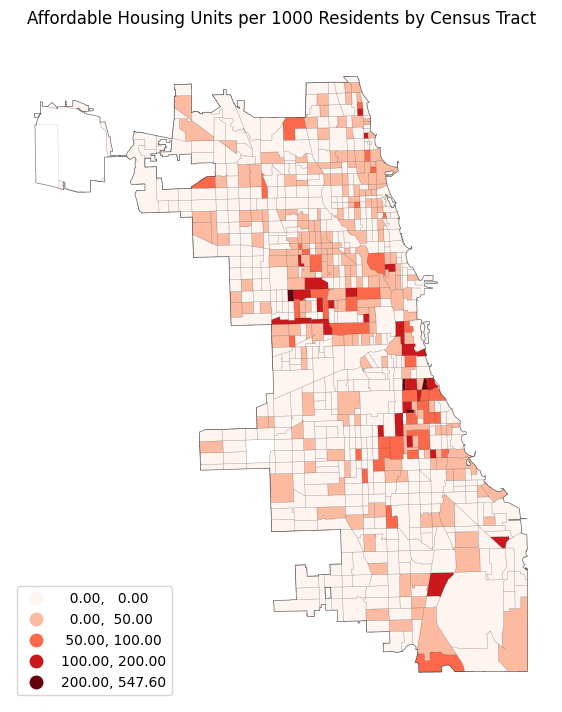

In [4]:
#fig, axes = plt.subplots(1,2, figsize=(10,8))



ax = gdf.plot(
    'affordable_units_per_1000',
    figsize=(7,10),
    cmap='Reds',
    scheme='userdefined',
    classification_kwds={'bins': [0, 50, 100, 200]},
    legend=True,
    legend_kwds={'loc': 3}
)

gdf.boundary.plot(ax=ax, lw=0.25, color='black', alpha=.25)

border.boundary.plot(ax=ax, lw=0.5, color='black', alpha=.5)

ax.set_title('Affordable Housing Units per 1000 Residents by Census Tract')
ax.set_axis_off()

plt.savefig('figures/housing_choropleth_map.png')

In [5]:
gdf['home_value_quartile'] = pd.qcut(gdf.median_home_value, q=4, labels=False) + 1
gdf['rent_quartile'] = pd.qcut(gdf.median_rent, q=4, labels=False) + 1
gdf['median_income_quartile'] = pd.qcut(gdf.median_income, q=4, labels=False) + 1
gdf['share_white_quartile'] = pd.qcut(gdf.share_white, q=4, labels=False) + 1

In [6]:
units_by_quartile = pd.DataFrame(
    {
        'By Median Home Value': gdf.groupby('home_value_quartile').affordable_units_per_1000.mean(),
        'By Median Rent': gdf.groupby('rent_quartile').affordable_units_per_1000.mean(),
        'By Median Income': gdf.groupby('median_income_quartile').affordable_units_per_1000.mean(),
        'By Share White': gdf.groupby('share_white_quartile').affordable_units_per_1000.mean(),
    }
)

In [7]:
units_by_quartile['Quartile'] = ['Bottom 25%', '25 - 50%', '50 - 75%', 'Top 25%']
table = units_by_quartile.reset_index().sort_values('index', ascending=False).set_index('Quartile')

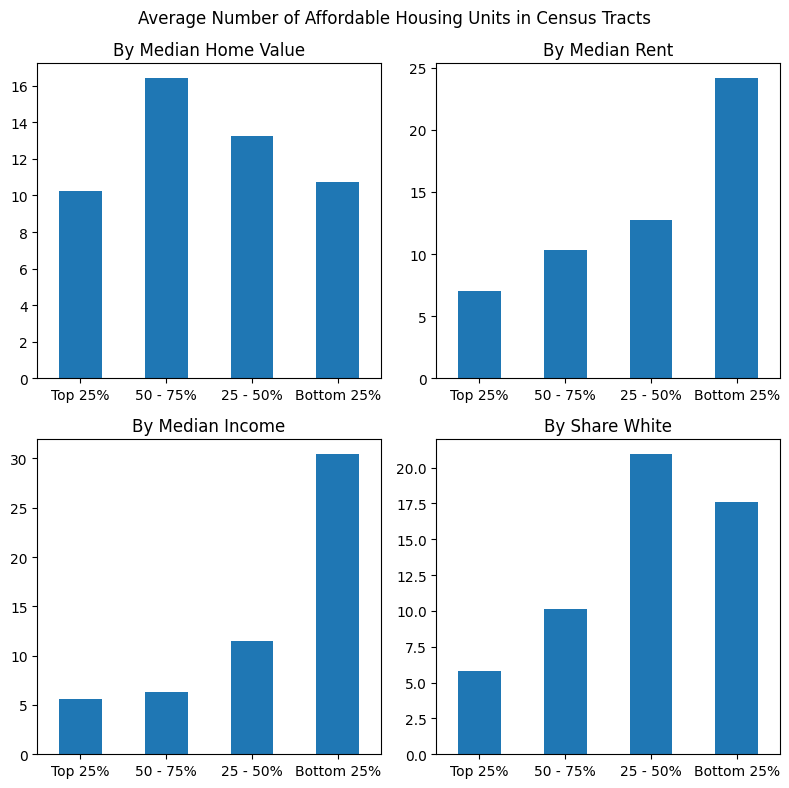

In [8]:
fig, axes = plt.subplots(2,2, figsize=(8,8), layout='tight')

axes = axes.flatten()

for col, ax in zip(table.columns[1:], axes):
  table.plot(
      y=col, 
      ax=ax,
      kind='bar',
      legend=False,
      title=col,
      xlabel=''
    )
  
  ax.tick_params(axis='x', labelrotation=0)


fig.suptitle('Average Number of Affordable Housing Units in Census Tracts')
plt.savefig('figures/housing_bar_charts.png')